In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
OUTPUT_DIR = "/content/drive/MyDrive/ml_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def out(f):
    return os.path.join(OUTPUT_DIR, f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import mean_squared_error, r2_score, precision_score, recall_score, f1_score, confusion_matrix, accuracy_score

In [ ]:
def load_heart():
    path = "/content/drive/MyDrive/processed_cleveland.csv"

    df = pd.read_csv(path)
    print("Columns:", df.columns.tolist())

    df.replace("?", np.nan, inplace=True)
    df = df.apply(pd.to_numeric)

    # create target from 'num'
    df["target"] = (df["num"] > 0).astype(int)
    df.drop(columns=["num"], inplace=True)

    return df


def load_diabetes():
    path = "/content/drive/MyDrive/diabetes.csv"

    df = pd.read_csv(path)
    print("Columns:", df.columns.tolist())

    if "Outcome" not in df.columns:
        raise ValueError("Target column 'Outcome' not found")

    return df

In [ ]:
def preprocess(df, target, zero_cols=None):
    df = df.copy()

    if zero_cols:
        for c in zero_cols:
            if c in df.columns:
                df[c] = df[c].replace(0, np.nan)

    X = df.drop(columns=[target])
    y = df[target]

    X = SimpleImputer(strategy="median").fit_transform(X)

    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    scaler = StandardScaler()
    Xtr = scaler.fit_transform(Xtr)
    Xte = scaler.transform(Xte)

    return Xtr, Xte, ytr, yte, scaler

In [ ]:
def regression(Xtr, Xte, ytr, yte):
    models = {
        "Linear": LinearRegression(),
        "Ridge": Ridge(alpha=1),
        "Lasso": Lasso(alpha=0.1)
    }

    for n, m in models.items():
        m.fit(Xtr, ytr)
        p = m.predict(Xte)
        print(n, "RMSE:", np.sqrt(mean_squared_error(yte, p)), "R2:", r2_score(yte, p))

In [ ]:
def classification(Xtr, Xte, ytr, yte):
    models = {
        "Logistic L1": LogisticRegression(penalty='l1', solver='liblinear'),
        "Logistic L2": LogisticRegression(),
        "DT": DecisionTreeClassifier(max_depth=5),
        "RF": RandomForestClassifier()
    }

    trained = {}

    for n, m in models.items():
        m.fit(Xtr, ytr)
        p = m.predict(Xte)

        print(n)
        print("Acc:", accuracy_score(yte, p),
              "Prec:", precision_score(yte, p),
              "Rec:", recall_score(yte, p),
              "F1:", f1_score(yte, p))

        trained[n] = m

    return trained

In [ ]:
def plot_cm(y, p):
    sns.heatmap(confusion_matrix(y, p), annot=True, fmt="d")
    plt.show()

In [ ]:
heart = load_heart()
diabetes = load_diabetes()

Xtr_h, Xte_h, ytr_h, yte_h, scaler_h = preprocess(heart, "target")

Xtr_d, Xte_d, ytr_d, yte_d, scaler_d = preprocess(
    diabetes, "Outcome",
    ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
)

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [ ]:
regression(Xtr_h, Xte_h, ytr_h, yte_h)
regression(Xtr_d, Xte_d, ytr_d, yte_d)

Linear RMSE: 0.3345678170208736 R2: 0.5492289419951022
Ridge RMSE: 0.3342120680328487 R2: 0.5501870502334085
Lasso RMSE: 0.38923968261625314 R2: 0.3898706481852461
Linear RMSE: 0.41436348664586686 R2: 0.2459317775123857
Ridge RMSE: 0.4143188889786721 R2: 0.24609408850233616
Lasso RMSE: 0.43186597419246486 R2: 0.18088353007776992


Logistic L1
Acc: 0.8688524590163934 Prec: 0.8125 Rec: 0.9285714285714286 F1: 0.8666666666666667
Logistic L2
Acc: 0.8688524590163934 Prec: 0.8125 Rec: 0.9285714285714286 F1: 0.8666666666666667
DT
Acc: 0.7377049180327869 Prec: 0.7 Rec: 0.75 F1: 0.7241379310344828
RF
Acc: 0.9180327868852459 Prec: 0.8709677419354839 Rec: 0.9642857142857143 F1: 0.9152542372881356


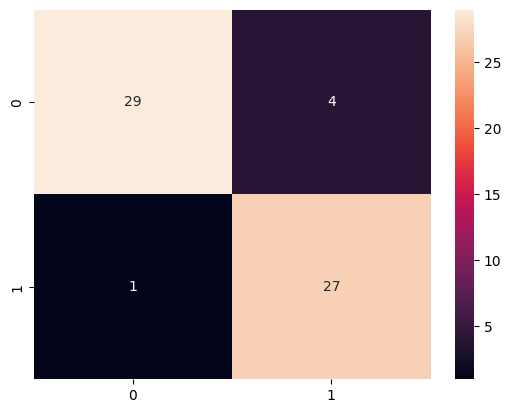

In [ ]:
clf = classification(Xtr_h, Xte_h, ytr_h, yte_h)

pred = clf["RF"].predict(Xte_h)
plot_cm(yte_h, pred)

In [ ]:
sample = np.array([[45,1,1,120,230,0,0,150,0,1.2,0,0,0]])

sample = scaler_h.transform(sample)

reg = Ridge().fit(Xtr_h, ytr_h)
clf_model = clf["RF"]

risk = reg.predict(sample)[0]
pred = clf_model.predict(sample)[0]

print("Risk:", risk)
print("Disease:", "YES" if pred==1 else "NO")

Risk: -0.2776200871695677
Disease: NO


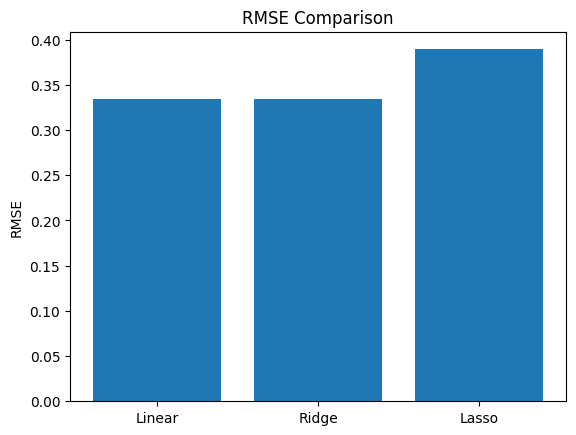

In [ ]:
import matplotlib.pyplot as plt

def plot_rmse(Xtr, Xte, ytr, yte):
    models = {
        "Linear": LinearRegression(),
        "Ridge": Ridge(alpha=1),
        "Lasso": Lasso(alpha=0.1)
    }

    names, rmses = [], []

    for n, m in models.items():
        m.fit(Xtr, ytr)
        p = m.predict(Xte)
        rmse = np.sqrt(mean_squared_error(yte, p))

        names.append(n)
        rmses.append(rmse)

    plt.figure()
    plt.bar(names, rmses)
    plt.title("RMSE Comparison")
    plt.ylabel("RMSE")
    plt.show()

plot_rmse(Xtr_h, Xte_h, ytr_h, yte_h)

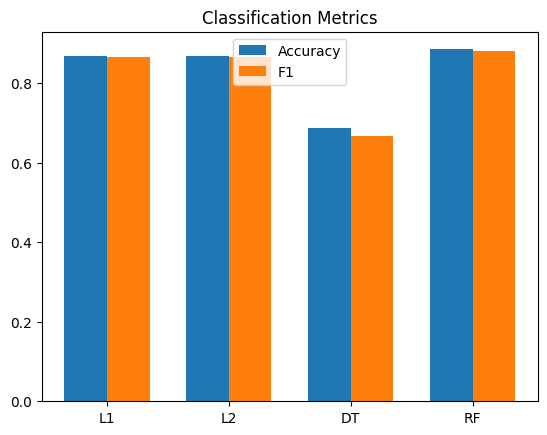

In [ ]:
def plot_metrics(Xtr, Xte, ytr, yte):
    models = {
        "L1": LogisticRegression(penalty='l1', solver='liblinear'),
        "L2": LogisticRegression(),
        "DT": DecisionTreeClassifier(max_depth=5),
        "RF": RandomForestClassifier()
    }

    acc, f1, names = [], [], []

    for n, m in models.items():
        m.fit(Xtr, ytr)
        p = m.predict(Xte)

        acc.append(accuracy_score(yte, p))
        f1.append(f1_score(yte, p))
        names.append(n)

    x = np.arange(len(names))
    width = 0.35

    plt.figure()
    plt.bar(x - width/2, acc, width, label="Accuracy")
    plt.bar(x + width/2, f1, width, label="F1")

    plt.xticks(x, names)
    plt.legend()
    plt.title("Classification Metrics")
    plt.show()

plot_metrics(Xtr_h, Xte_h, ytr_h, yte_h)

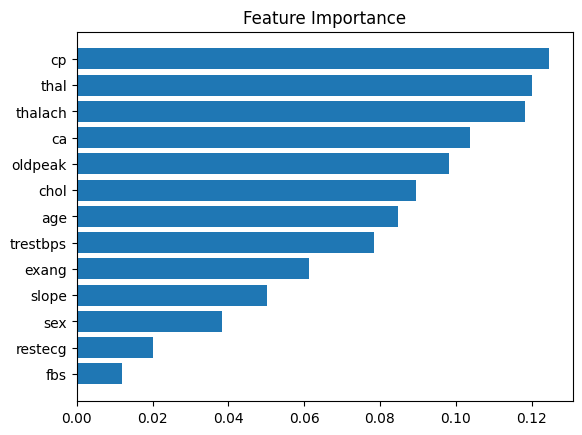

In [ ]:
def plot_importance(model, feature_names):
    imp = model.feature_importances_
    idx = np.argsort(imp)

    plt.figure()
    plt.barh(range(len(idx)), imp[idx])
    plt.yticks(range(len(idx)), np.array(feature_names)[idx])
    plt.title("Feature Importance")
    plt.show()

feature_names = heart.drop(columns=["target"]).columns
plot_importance(clf["RF"], feature_names)

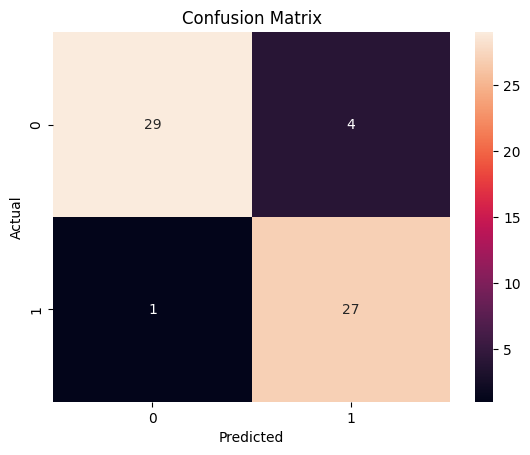

In [ ]:
import seaborn as sns

def plot_cm_full(y, p):
    plt.figure()
    sns.heatmap(confusion_matrix(y, p), annot=True, fmt="d")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

pred = clf["RF"].predict(Xte_h)
plot_cm_full(yte_h, pred)

In [ ]:
def plot_user_vs_dataset(user, df, features):
    user = user.flatten()
    means = df[features].mean()

    x = np.arange(len(features))

    plt.figure()
    plt.bar(x - 0.2, means, 0.4, label="Dataset")
    plt.bar(x + 0.2, user, 0.4, label="User")
    plt.xticks(x, features, rotation=45)
    plt.legend()
    plt.show()


def plot_risk(risk):
    plt.figure()
    plt.bar(["Risk"], [risk])
    plt.axhline(0.3)
    plt.axhline(0.6)
    plt.show()


def plot_prob(model, user_scaled):
    prob = model.predict_proba(user_scaled)[0]
    plt.figure()
    plt.bar(["No", "Yes"], prob)
    plt.show()

In [ ]:
def get_user_input():
    print("Enter Patient Details:\n")

    age = float(input("Age: "))
    sex = int(input("Sex (0=Female, 1=Male): "))
    cp = int(input("Chest Pain (0/1): "))
    bp = float(input("Systolic BP: "))
    chol = float(input("Cholesterol: "))
    fbs = int(input("Fasting Blood Sugar (0/1): "))
    restecg = 0
    thalach = float(input("Max Heart Rate: "))
    exang = int(input("Exercise Angina (0/1): "))
    oldpeak = float(input("Oldpeak: "))
    slope = 0
    ca = 0
    thal = 0

    data = [
        age, sex, cp, bp, chol, fbs,
        restecg, thalach, exang, oldpeak,
        slope, ca, thal
    ]

    return np.array(data).reshape(1, -1)

Enter Patient Details:

Age: 34
Sex (0=Female, 1=Male): 0
Chest Pain (0/1): 0
Systolic BP: 100
Cholesterol: 89
Fasting Blood Sugar (0/1): 0
Max Heart Rate: 120
Exercise Angina (0/1): 1
Oldpeak: 0.2

Risk: -0.43
Disease: NO


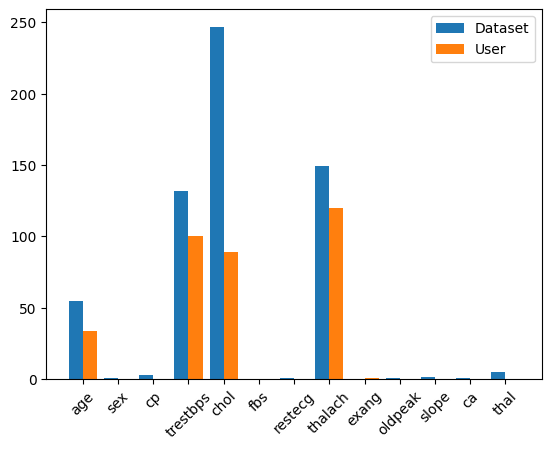

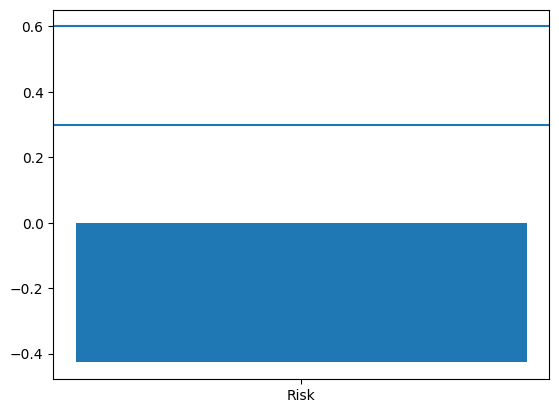

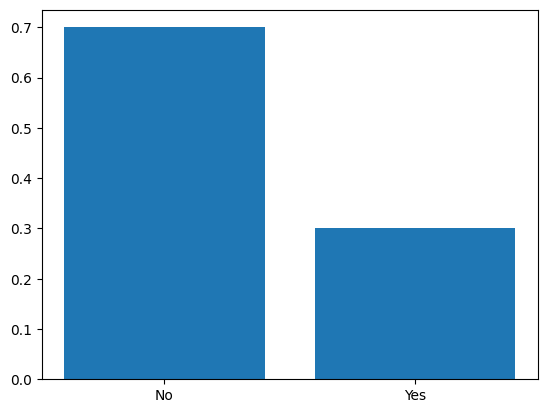

In [ ]:
user = get_user_input()

user_scaled = scaler_h.transform(user)

reg = Ridge().fit(Xtr_h, ytr_h)
clf_model = clf["RF"]

risk = reg.predict(user_scaled)[0]
pred = clf_model.predict(user_scaled)[0]

print("\nRisk:", round(risk,2))
print("Disease:", "YES" if pred==1 else "NO")

features = heart.drop(columns=["target"]).columns

plot_user_vs_dataset(user, heart, features)
plot_risk(risk)
plot_prob(clf_model, user_scaled)